Import Library

In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Set Path Dataset

In [4]:
BASE_DIR = "../data/raw"

NIH_PATH = os.path.join(BASE_DIR, "chestxray14")
CHEXPERT_PATH = os.path.join(BASE_DIR, "chexpert")
TBX11K_PATH = os.path.join(BASE_DIR, "tbx11k")

Load NIH Metadata

In [5]:
nih_df = pd.read_csv(
    os.path.join(NIH_PATH, "Data_Entry_2017.csv")
)

print("NIH Dataset Shape:")
print(nih_df.shape)

nih_df.head()

NIH Dataset Shape:
(112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


Cek Distribusi NIH Label

In [6]:
nih_df["Finding Labels"].value_counts().head(20)

Finding Labels
No Finding                           60412
Infiltration                          9551
Atelectasis                           4212
Effusion                              3959
Nodule                                2706
Pneumothorax                          2199
Mass                                  2138
Effusion|Infiltration                 1602
Atelectasis|Infiltration              1356
Consolidation                         1314
Atelectasis|Effusion                  1167
Pleural_Thickening                    1127
Cardiomegaly                          1094
Emphysema                              895
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      740
Fibrosis                               727
Edema                                  634
Cardiomegaly|Effusion                  483
Consolidation|Infiltration             442
Name: count, dtype: int64

Hitung Jumlah Cardiomegaly NIH

In [7]:
cardio_count = nih_df["Finding Labels"].str.contains(
    "Cardiomegaly",
    na=False
).sum()

print("Jumlah Cardiomegaly NIH:", cardio_count)

Jumlah Cardiomegaly NIH: 2772


Load CheXpert Metadata

In [8]:
chexpert_train = pd.read_csv(
    os.path.join(CHEXPERT_PATH, "train.csv")
)

chexpert_valid = pd.read_csv(
    os.path.join(CHEXPERT_PATH, "valid.csv")
)

print("CheXpert Train Shape:")
print(chexpert_train.shape)

chexpert_train.head()

CheXpert Train Shape:
(223414, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


Distribusi Cardiomegaly CheXpert

In [9]:
print(
    chexpert_train["Cardiomegaly"].value_counts(dropna=False)
)

Cardiomegaly
 NaN    177211
 1.0     27000
 0.0     11116
-1.0      8087
Name: count, dtype: int64


Hitung Jumlah Image TBX11K

In [10]:
tb_path = os.path.join(TBX11K_PATH, "imgs", "tb")
health_path = os.path.join(TBX11K_PATH, "imgs", "health")
sick_path = os.path.join(TBX11K_PATH, "imgs", "sick")

tb_count = len(os.listdir(tb_path))
health_count = len(os.listdir(health_path))
sick_count = len(os.listdir(sick_path))

print("TB Images:", tb_count)
print("Healthy Images:", health_count)
print("Sick Images:", sick_count)

TB Images: 800
Healthy Images: 3800
Sick Images: 3800


Visualisasi Distribusi TBX11K

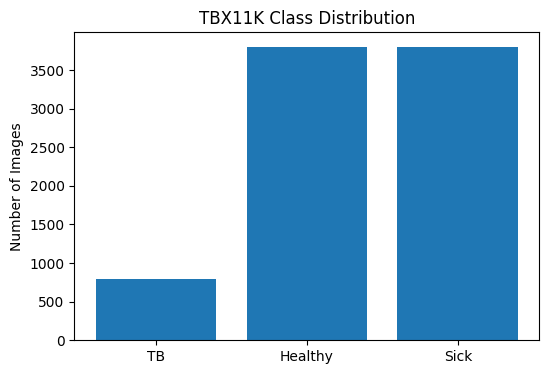

In [11]:
labels = ["TB", "Healthy", "Sick"]
counts = [tb_count, health_count, sick_count]

plt.figure(figsize=(6,4))

plt.bar(labels, counts)

plt.title("TBX11K Class Distribution")
plt.ylabel("Number of Images")

plt.show()

Tampilkan Sample Image NIH

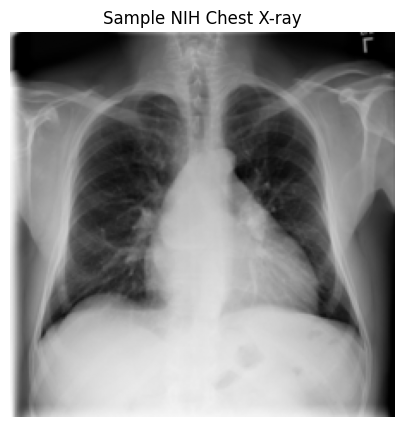

In [12]:
sample_img = os.path.join(
    NIH_PATH,
    "images",
    nih_df.iloc[0]["Image Index"]
)

img = Image.open(sample_img)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Sample NIH Chest X-ray")
plt.axis("off")
plt.show()